In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

In [4]:
data = [
    3.8, 24.1, 10.5, 7.3, 1.4, 1.4, 0.5, 16.1, 7.4, 9.9,
    0.2, 28.0, 14.3, 1.9, 1.6, 1.6, 2.9, 6.0, 4.5, 2.8,
    7.6, 1.2, 2.8, 3.7, 4.9, 12.3, 1.8, 5.8, 7.2, 0.4,
    7.5, 1.5, 0.5, 23.8, 27.0, 13.2, 2.9, 0.8, 9.2, 4.6,
    1.0, 5.5, 0.3, 19.2, 2.4, 8.7, 3.0, 5.9, 6.3, 1.6,
    27.9, 11.9, 22.4, 18.0, 7.3, 20.4, 0.7, 1.7, 0.4, 3.1
]

## 1. Критерий Манна-Уитни

**Задача**: Сравнить время обработки заявок в старой и новой версиях системы.

**Гипотезы**:
- $H_0: F_{ст}(x) = F_{нов}(x)$ (распределения совпадают)
- $H_1: F_{ст}(x) \neq F_{нов}(x)$ (распределения различаются)

### Формулы расчёта

**1. U-статистика для старой версии:**
$$U_{ст} = R_{ст} - \frac{n_1(n_1+1)}{2}$$

**2. U-статистика для новой версии:**
$$U_{нов} = R_{нов} - \frac{n_2(n_2+1)}{2}$$

**3. Тестовая статистика:**
$$U = \min(U_{ст}, U_{нов})$$

где:
- $R_{ст}$ — сумма рангов выборки старой версии
- $R_{нов}$ — сумма рангов выборки новой версии
- $n_1$ — размер выборки старой версии
- $n_2$ — размер выборки новой версии

**4. p-value:** определяется по таблице точного распределения критерия Манна–Уитни

In [13]:
old_version = data[:10]
new_version = data[30:40]

print(f"Выборка из старой версии (n₁={len(old_version)}):")
print(old_version)
print(f"Выборка из новой версии (n₂={len(new_version)}):")
print(new_version)

n1 = len(old_version)
n2 = len(new_version)

# Объединяем выборки и назначаем ранги
combined = old_version + new_version
ranks = stats.rankdata(combined)

# Ранги для каждой выборки
ranks_old = ranks[:n1]
ranks_new = ranks[n1:]

print(f"\nОбъединенная выборка с рангами:")
print(f"Ранги старой версии: {ranks_old}")
print(f"Ранги новой версии: {ranks_new}")

# Суммы рангов
R_old = np.sum(ranks_old)
R_new = np.sum(ranks_new)

print(f"\nСумма рангов старой версии: R_ст = {R_old}")
print(f"Сумма рангов новой версии: R_нов = {R_new}")

# Формула для расчета U статистики:

U_old = R_old - (n1 * (n1 + 1)) / 2
U_new = R_new - (n2 * (n2 + 1)) / 2
U = min(U_old, U_new)

print(f"\nРасчет статистики U по формулам:")
print(f"U_ст = R_ст - n_1(n_1+1)/2 = {R_old} - {n1}*{n1+1}/2 = {R_old} - {n1*(n1+1)/2} = {U_old}")
print(f"U_нов = R_нов - n_2(n_2+1)/2 = {R_new} - {n2}*{n2+1}/2 = {R_new} - {n2*(n2+1)/2} = {U_new}")
print(f"U = min(U_ст, U_нов) = min({U_old}, {U_new}) = {U}")

# Применяем встроенный критерий Манна-Уитни
statistic, p_value_mw = stats.mannwhitneyu(old_version, new_version, alternative='two-sided')

print(f"\nРезультаты критерия Манна-Уитни:")
print(f"Статистика U = {statistic}")
print(f"p-value = {p_value_mw:.4f}")

if p_value_mw > 0.05:
    print(f"Вывод: Так как p = {p_value_mw:.4f} > 0.05 = alpha, нулевая гипотеза не отвергается.")
    print("Статистически значимых различий между двумя выборками не обнаружено.")
else:
    print(f"Вывод: Так как p = {p_value_mw:.4f} < 0.05 = alpha, нулевая гипотеза отвергается.")
    print("Выборки статистически значимо различаются.")

Выборка из старой версии (n₁=10):
[3.8, 24.1, 10.5, 7.3, 1.4, 1.4, 0.5, 16.1, 7.4, 9.9]
Выборка из новой версии (n₂=10):
[7.5, 1.5, 0.5, 23.8, 27.0, 13.2, 2.9, 0.8, 9.2, 4.6]

Объединенная выборка с рангами:
Ранги старой версии: [ 8.  19.  15.  10.   4.5  4.5  1.5 17.  11.  14. ]
Ранги новой версии: [12.   6.   1.5 18.  20.  16.   7.   3.  13.   9. ]

Сумма рангов старой версии: R_ст = 104.5
Сумма рангов новой версии: R_нов = 105.5

Расчет статистики U по формулам:
U_ст = R_ст - n_1(n_1+1)/2 = 104.5 - 10*11/2 = 104.5 - 55.0 = 49.5
U_нов = R_нов - n_2(n_2+1)/2 = 105.5 - 10*11/2 = 105.5 - 55.0 = 50.5
U = min(U_ст, U_нов) = min(49.5, 50.5) = 49.5

Результаты критерия Манна-Уитни:
Статистика U = 49.5
p-value = 1.0000
Вывод: Так как p = 1.0000 > 0.05 = alpha, нулевая гипотеза не отвергается.
Статистически значимых различий между двумя выборками не обнаружено.


/tmp/ipykernel_26118/602666009.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([old_version, new_version], labels=['Старая версия', 'Новая версия'])


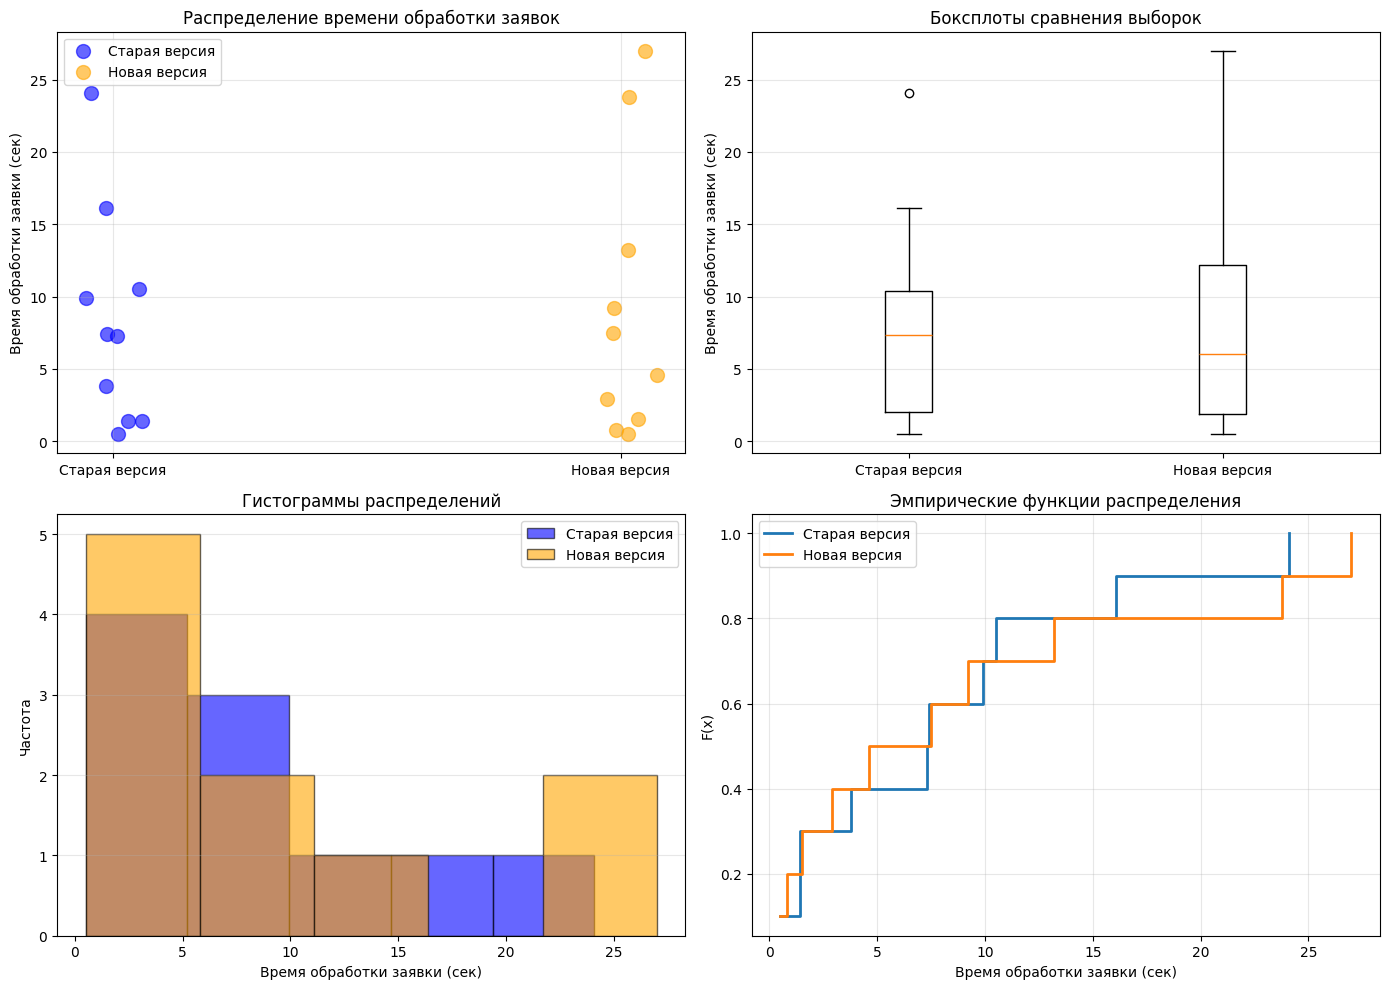

In [14]:
# Визуализация для Манна-Уитни
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
positions_old = np.random.normal(1, 0.04, len(old_version))
positions_new = np.random.normal(2, 0.04, len(new_version))
ax.scatter(positions_old, old_version, alpha=0.6, s=100, label='Старая версия', color='blue')
ax.scatter(positions_new, new_version, alpha=0.6, s=100, label='Новая версия', color='orange')
ax.set_xticks([1, 2])
ax.set_xticklabels(['Старая версия', 'Новая версия'])
ax.set_ylabel('Время обработки заявки (сек)')
ax.set_title('Распределение времени обработки заявок')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.boxplot([old_version, new_version], labels=['Старая версия', 'Новая версия'])
ax.set_ylabel('Время обработки заявки (сек)')
ax.set_title('Боксплоты сравнения выборок')
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 0]
ax.hist(old_version, alpha=0.6, bins=5, label='Старая версия', color='blue', edgecolor='black')
ax.hist(new_version, alpha=0.6, bins=5, label='Новая версия', color='orange', edgecolor='black')
ax.set_xlabel('Время обработки заявки (сек)')
ax.set_ylabel('Частота')
ax.set_title('Гистограммы распределений')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 1]
sorted_old = np.sort(old_version)
sorted_new = np.sort(new_version)
ecdf_old = np.arange(1, len(sorted_old) + 1) / len(sorted_old)
ecdf_new = np.arange(1, len(sorted_new) + 1) / len(sorted_new)

ax.step(sorted_old, ecdf_old, where='post', label='Старая версия', linewidth=2)
ax.step(sorted_new, ecdf_new, where='post', label='Новая версия', linewidth=2)
ax.set_xlabel('Время обработки заявки (сек)')
ax.set_ylabel('F(x)')
ax.set_title('Эмпирические функции распределения')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mann_whitney_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

## 2. Критерий Пирсона χ²

**Задача**: Проверить гипотезу о том, что время между поступлениями заявок имеет экспоненциальное распределение.

**Гипотезы**:
- $H_0: X \sim \text{Exp}_\lambda$ (данные имеют экспоненциальное распределение)
- $H_1: X \not\sim \text{Exp}_\lambda$ (данные не имеют экспоненциального распределения)

### Формулы расчёта

**1. Оценка параметра λ:**
$$\hat{\lambda} = \frac{1}{\bar{x}}$$

где $\bar{x}$ — выборочное среднее

**2. Функция распределения экспоненциального закона:**
$$F(x) = 1 - e^{-\lambda x}$$

**3. Квантили для разбиения данных:**
$$x_p = -\frac{\ln(1-p)}{\lambda}$$

**4. Статистика Пирсона χ²:**
$$\chi^{2}_{набл} = \sum_{i=1}^{k} \frac{(n_i - n \cdot p_i)^{2}}{n \cdot p_i}$$

где:
- $n_i$ — наблюдаемая частота в i-м интервале
- $n \cdot p_i$ — ожидаемая частота в i-м интервале
- $p_i$ — теоретическая вероятность для i-го интервала
- $k$ — число интервалов

**5. Число степеней свободы:**
$$r = k - s - 1$$

где $s$ — число параметров, оцененных по выборке (для экспоненциального распределения $s = 1$)

**6. Критическое значение:**
$$\chi^2_{\alpha, r} \text{ — из таблицы распределения хи-квадрат}$$

**7. Вывод:**
- Если $\chi^{2}_{набл} < \chi^{2}_{\alpha, r}$, то нулевая гипотеза не отвергается
- Если $\chi^{2}_{набл} \geq \chi^{2}_{\alpha, r}$, то нулевая гипотеза отвергается

In [20]:
data_array = np.array(data)
n = len(data_array)

print(f"\nОбщее количество наблюдений: n = {n}")

x_mean = np.mean(data_array)
lambda_est = 1 / x_mean

print(f"\n2.3a. Оценка параметра lambda:")
print(f"Формула: lambda = 1/avg(x)")
print(f"avg(x) = {x_mean:.4f}")
print(f"lambda = 1/{x_mean:.4f} = {lambda_est:.4f}")


probs = np.array([0.2, 0.4, 0.6, 0.8, 1.0])
quantiles = -np.log(1 - probs) / lambda_est

print(f"\nТеоретические вероятности в каждом интервале: p_i = 0.2")
print(f"\nКвантили (границы интервалов):")
print(f"x_0.2 = {quantiles[0]:.4f}")
print(f"x_0.4 = {quantiles[1]:.4f}")
print(f"x_0.6 = {quantiles[2]:.4f}")
print(f"x_0.8 = {quantiles[3]:.4f}")



# Границы интервалов
boundaries = np.array([0] + list(quantiles[:-1]))
print(f"\nГраницы интервалов: {boundaries}")

# Подсчет наблюдаемых частот
intervals = [(boundaries[i], quantiles[i]) for i in range(5)]
observed_freq = np.zeros(5)

for i, (lower, upper) in enumerate(intervals):
    count = np.sum((data_array > lower) & (data_array <= upper))
    observed_freq[i] = count
    print(f"Интервал {i+1}: ({lower:.2f}, {upper:.2f}] - частота n_{i+1} = {int(count)}")





print(f"\nНаблюдаемые частоты: n_i = {observed_freq.astype(int)}")
print(f"Сумма частот: {int(np.sum(observed_freq))} = n")

# 2.3d. Теоретические вероятности и ожидаемые частоты
theoretical_probs = np.ones(5) * 0.2  # p_i = 0.2 для каждого интервала
expected_freq = theoretical_probs * n

print(f"\n2.3d. Теоретические вероятности и ожидаемые частоты:")
print(f"Теоретические вероятности: p_i = 0.2 для всех i")
print(f"Ожидаемые частоты: np_i = {expected_freq}")




chi_squared = np.sum((observed_freq - expected_freq)**2 / expected_freq)

print(f"\n2.3e. Расчет статистики Пирсона chi^2:")
print(f"\nДетальный расчет:")
for i in range(5):
    contrib = (observed_freq[i] - expected_freq[i])**2 / expected_freq[i]
    print(f"Интервал {i+1}: {contrib:.4f}")

print(f"\nchi^2_набл = {chi_squared:.4f}")

# 2.4 Число степеней свободы
k = 5
s = 1
r = k - 1 - s

print(f"\n2.4. Число степеней свободы:")
print(f"Формула: r = k - 1 - s")
print(f"где k = {k} (количество интервалов)")
print(f"s = {s} (количество оцененных параметров)")
print(f"r = {k} - 1 - {s} = {r}")


alpha = 0.05
chi_squared_critical = stats.chi2.ppf(1 - alpha, r)

print(f"\n2.5. Критическое значение:")
print(f"Уровень значимости alpha = {alpha}")
print(f"chi²_крит = χ²_{alpha},{r} = {chi_squared_critical:.4f}")

# 2.6 Вывод
print(f"\n2.6. Вывод:")
print(f"chi^2_набл = {chi_squared:.4f}")
print(f"chi^2_крит = {chi_squared_critical:.4f}")

if chi_squared < chi_squared_critical:
    print(f"\nТак как chi^2_набл ({chi_squared:.4f}) < chi^2_крит ({chi_squared_critical:.4f}),")
    print("нулевая гипотеза не отвергается.")
    print("Полученные данные не противоречат гипотезе о том, что время")
    print("между поступлениями заявок имеет экспоненциальное распределение.")
else:
    print(f"\nТак как chi^2_набл ({chi_squared:.4f}) > chi^2_крит ({chi_squared_critical:.4f}),")
    print("нулевая гипотеза отвергается.")
    print("Данные противоречат гипотезе об экспоненциальном распределении.")


Общее количество наблюдений: n = 60

2.3a. Оценка параметра lambda:
Формула: lambda = 1/avg(x)
avg(x) = 7.5433
lambda = 1/7.5433 = 0.1326

Теоретические вероятности в каждом интервале: p_i = 0.2

Квантили (границы интервалов):
x_0.2 = 1.6832
x_0.4 = 3.8533
x_0.6 = 6.9119
x_0.8 = 12.1405

Границы интервалов: [ 0.          1.68324619  3.85332796  6.91188642 12.14052665]
Интервал 1: (0.00, 1.68] - частота n_1 = 16
Интервал 2: (1.68, 3.85] - частота n_2 = 12
Интервал 3: (3.85, 6.91] - частота n_3 = 8
Интервал 4: (6.91, 12.14] - частота n_4 = 11
Интервал 5: (12.14, inf] - частота n_5 = 13

Наблюдаемые частоты: n_i = [16 12  8 11 13]
Сумма частот: 60 = n

2.3d. Теоретические вероятности и ожидаемые частоты:
Теоретические вероятности: p_i = 0.2 для всех i
Ожидаемые частоты: np_i = [12. 12. 12. 12. 12.]

2.3e. Расчет статистики Пирсона chi^2:

Детальный расчет:
Интервал 1: 1.3333
Интервал 2: 0.0000
Интервал 3: 1.3333
Интервал 4: 0.0833
Интервал 5: 0.0833

chi^2_набл = 2.8333

2.4. Число степе

/tmp/ipykernel_26118/4178946497.py:16: RuntimeWarning: divide by zero encountered in log
  quantiles = -np.log(1 - probs) / lambda_est


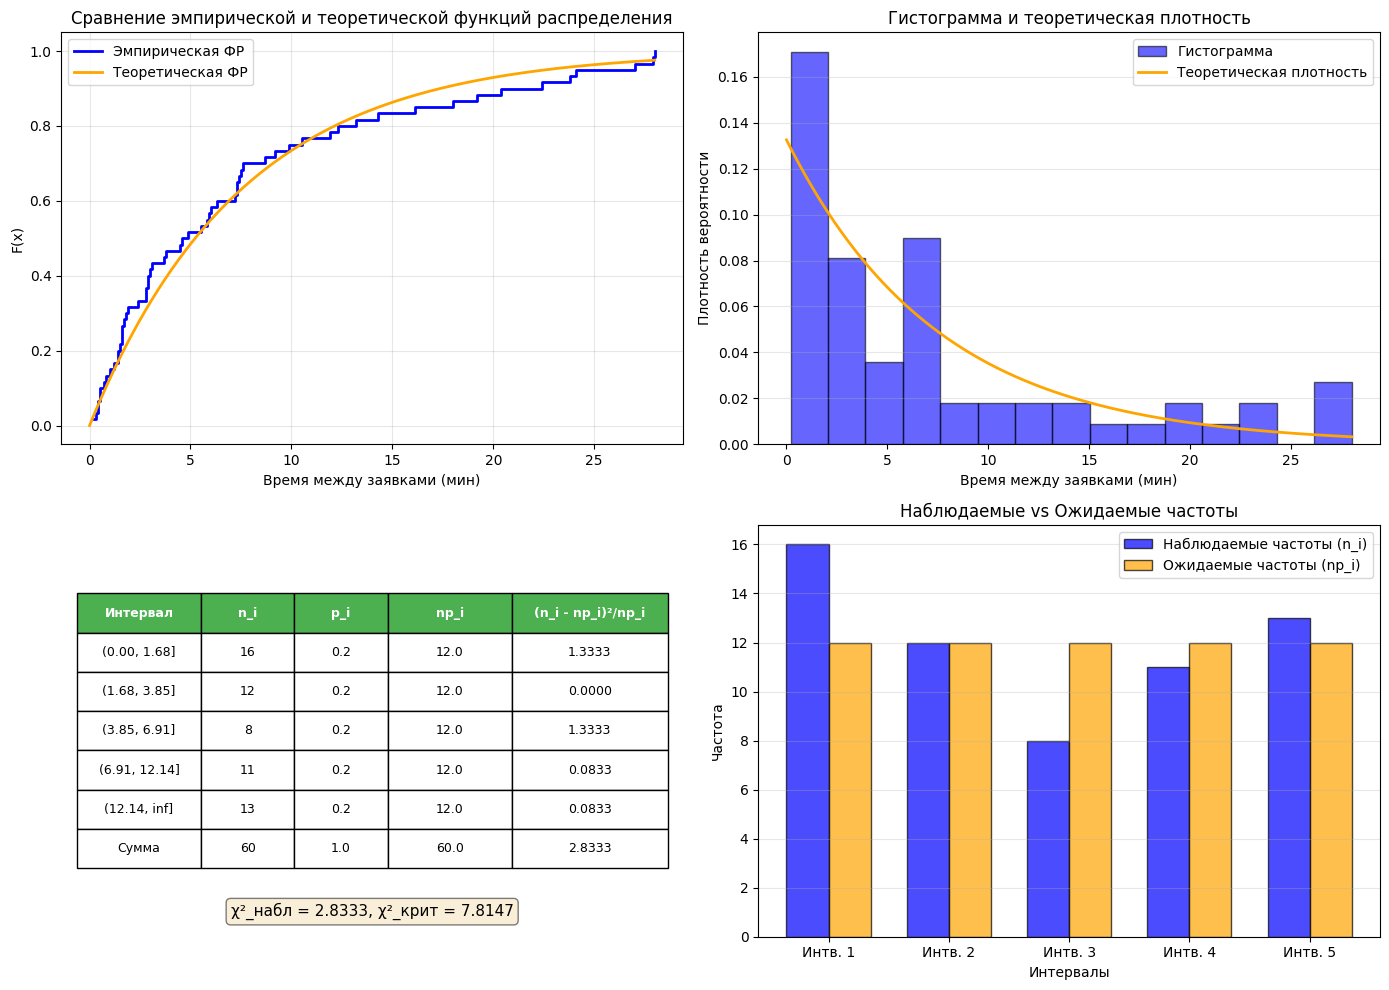

In [23]:
# 2.7 Визуализация для критерия Пирсона
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Эмпирическая функция распределения и теоретическая ФР
ax = axes[0, 0]
sorted_data = np.sort(data_array)
empirical_cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

# Теоретическая ФР экспоненциального распределения
x_range = np.linspace(0, np.max(sorted_data), 1000)
theoretical_cdf = 1 - np.exp(-lambda_est * x_range)

ax.step(sorted_data, empirical_cdf, where='post', label='Эмпирическая ФР', linewidth=2, color='blue')
ax.plot(x_range, theoretical_cdf, label='Теоретическая ФР', linewidth=2, color='orange')
ax.set_xlabel('Время между заявками (мин)')
ax.set_ylabel('F(x)')
ax.set_title('Сравнение эмпирической и теоретической функций распределения')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Гистограмма и теоретическая плотность
ax = axes[0, 1]
counts, bins, patches = ax.hist(data_array, bins=15, density=True, alpha=0.6, 
                                color='blue', edgecolor='black', label='Гистограмма')

# Теоретическая плотность распределения
x_range = np.linspace(0, np.max(data_array), 1000)
theoretical_pdf = lambda_est * np.exp(-lambda_est * x_range)
ax.plot(x_range, theoretical_pdf, color='orange', linewidth=2, label='Теоретическая плотность')

ax.set_xlabel('Время между заявками (мин)')
ax.set_ylabel('Плотность вероятности')
ax.set_title('Гистограмма и теоретическая плотность')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 3. Таблица расчетов
ax = axes[1, 0]
ax.axis('off')

# Создаем таблицу с расчетами
table_data = []
table_data.append(['Интервал', 'n_i', 'p_i', 'np_i', '(n_i - np_i)²/np_i'])

for i in range(5):
    interval_str = f"({boundaries[i]:.2f}, {quantiles[i]:.2f}]"
    ni = observed_freq[i]
    pi = theoretical_probs[i]
    npi = expected_freq[i]
    chi_contrib = (ni - npi)**2 / npi
    table_data.append([interval_str, f"{int(ni)}", f"{pi:.1f}", f"{npi:.1f}", f"{chi_contrib:.4f}"])

table_data.append(['Сумма', f"{int(np.sum(observed_freq))}", '1.0', f"{np.sum(expected_freq):.1f}", f"{chi_squared:.4f}"])

table = ax.table(cellText=table_data, cellLoc='center', loc='center',
                colWidths=[0.2, 0.15, 0.15, 0.2, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Выделяем заголовок
for i in range(5):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')

ax.text(0.5, 0.05, f'χ²_набл = {chi_squared:.4f}, χ²_крит = {chi_squared_critical:.4f}',
        ha='center', transform=ax.transAxes, fontsize=11, bbox=dict(boxstyle='round', 
        facecolor='wheat', alpha=0.5))

# 4. Столбчатая диаграмма наблюдаемых и ожидаемых частот
ax = axes[1, 1]
x_pos = np.arange(5)
width = 0.35

bars1 = ax.bar(x_pos - width/2, observed_freq, width, label='Наблюдаемые частоты (n_i)', 
               color='blue', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x_pos + width/2, expected_freq, width, label='Ожидаемые частоты (np_i)', 
               color='orange', alpha=0.7, edgecolor='black')

ax.set_xlabel('Интервалы')
ax.set_ylabel('Частота')
ax.set_title('Наблюдаемые vs Ожидаемые частоты')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'Интв. {i+1}' for i in range(5)])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('pearson_chi_squared_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

In [22]:
# Создание итоговых таблиц
print("\n" + "="*70)
print("ИТОГОВЫЕ ТАБЛИЦЫ РАСЧЕТОВ")
print("="*70)

# Таблица для Манна-Уитни
print("\n1. КРИТЕРИЙ МАННА-УИТНИ")
print("-" * 70)
mw_table = pd.DataFrame({
    'Выборка': ['Старая версия', 'Новая версия'],
    'Размер (n)': [n1, n2],
    'Сумма рангов (R)': [R_old, R_new],
    'Статистика U': [U_old, U_new]
})
print(mw_table.to_string(index=False))
print(f"\nПолученное значение U = {U}")
print(f"p-value = {p_value_mw:.4f}")
print(f"Вывод: p > 0.05 → нулевая гипотеза не отвергается")

# Таблица для Пирсона
print("\n\n2. КРИТЕРИЙ ПИРСОНА χ²")
print("-" * 70)

pearson_table_data = {
    'Интервал': [f"({boundaries[i]:.3f}, {quantiles[i]:.3f}]" for i in range(5)],
    'n_i': [int(observed_freq[i]) for i in range(5)],
    'p_i': [f"{theoretical_probs[i]:.2f}" for i in range(5)],
    'np_i': [f"{expected_freq[i]:.1f}" for i in range(5)],
    '(n_i - np_i)²': [f"{(observed_freq[i] - expected_freq[i])**2:.3f}" for i in range(5)],
    '(n_i - np_i)²/np_i': [f"{(observed_freq[i] - expected_freq[i])**2 / expected_freq[i]:.4f}" for i in range(5)]
}

pearson_df = pd.DataFrame(pearson_table_data)
print(pearson_df.to_string(index=False))
print(f"\nПараметр распределения: λ̂ = {lambda_est:.4f}")
print(f"Статистика Пирсона: χ²_набл = {chi_squared:.4f}")
print(f"Критическое значение: χ²_крит ({r} степеней свободы) = {chi_squared_critical:.4f}")
print(f"Вывод: χ²_набл < χ²_крит → нулевая гипотеза не отвергается")

print("\n" + "="*70)
print("ЗАКЛЮЧЕНИЕ")
print("="*70)
print("\n1. По критерию Манна-Уитни:")
print("   Статистически значимых различий между выборками не найдено (p > 0.05).")
print("\n2. По критерию Пирсона χ²:")
print("   Данные не противоречат гипотезе об экспоненциальном распределении.")
print(f"   Время между поступлениями заявок соответствует распределению Exp({lambda_est:.4f}).")
print("="*70)


ИТОГОВЫЕ ТАБЛИЦЫ РАСЧЕТОВ

1. КРИТЕРИЙ МАННА-УИТНИ
----------------------------------------------------------------------
      Выборка  Размер (n)  Сумма рангов (R)  Статистика U
Старая версия          10             104.5          49.5
 Новая версия          10             105.5          50.5

Полученное значение U = 49.5
p-value = 1.0000
Вывод: p > 0.05 → нулевая гипотеза не отвергается


2. КРИТЕРИЙ ПИРСОНА χ²
----------------------------------------------------------------------
       Интервал  n_i  p_i np_i (n_i - np_i)² (n_i - np_i)²/np_i
 (0.000, 1.683]   16 0.20 12.0        16.000             1.3333
 (1.683, 3.853]   12 0.20 12.0         0.000             0.0000
 (3.853, 6.912]    8 0.20 12.0        16.000             1.3333
(6.912, 12.141]   11 0.20 12.0         1.000             0.0833
  (12.141, inf]   13 0.20 12.0         1.000             0.0833

Параметр распределения: λ̂ = 0.1326
Статистика Пирсона: χ²_набл = 2.8333
Критическое значение: χ²_крит (3 степеней свободы) =